In [10]:
# Preliminary features & parameters
import src.simulations.backtest_portfolio_v2 as bp
from src import indicators

features = {
        'sma_trend_regime': {
            'func': indicators.calculate_sma_crossover,
            'params': {'fast_window': 10, 'slow_window': 30, 'binary': True},
        },
        'sma_position_fast': {
            'func': indicators.calculate_sma_position,
            'params': {'window': 10},
        },
        'sma_position_slow': {
            'func': indicators.calculate_sma_position,
            'params': {'window': 30}
        },
        'rsi': {
            'func': indicators.calculate_rsi,
            'params': {'window': 14},
        },
        'bollinger_position': {
            'func': indicators.calculate_bollinger_position,
            'params': {'window': 20, 'num_std': 2},
        },
        'price_roc_fast': {
            'func': indicators.calculate_roc,
            'params': {'window': 1}
        },
        'price_roc_slow': {
            'func': indicators.calculate_roc,
            'params': {'window': 5}
        },
    }

# Use QQQ
ticker_pool_tech = [
        "NVDA", "MSFT", "AVGO", "NOW",
        "ORCL", "AAPL", "TEAM", "INTC",
        "SNOW", "WIX",  "AMD",  "CSCO",
        "SHOP", "AMZN", "CRM",
    ]

# Use SPY
ticker_pool_general = [
    "NVDA", "MSFT", "AAPL", "AMZN", "GOOGL",
    "UNH", "LLY", "JNJ",
    "XOM", "CVX",
    "JPM", "BRK-B",
    "WMT", "PG",
    "GLD"
]

ticker_pool_general = [
    "NVDA", "MSFT", "AAPL", "AMZN", "GOOGL",
    "UNH", "LLY", "JNJ",
    "XOM", "CVX",
    "JPM", "BRK-B",
    "WMT", "PG",
    "GLD", "SPY"
]

ticker_pool_etfs = [
    "XLK", # Technology
    "XLV", # Healthcare
    "XLE", # Energy
    "XLF", # Financials
    "XLP", # Consumer Staples
    "XLY", # Consumer Discretionary
    "XLI", # Industrials
    "XLB", # Materials
    "XLU", # Utilities
    "XLRE",# Real Estate
    "XLC", # Communication Services
    "GLD", # Gold
    "TLT", # Long-term Bonds
    "IYZ", # Telecom
    "VNQ", # REITs
]

ticker_pool_balanced = [
    "NVDA", "LLY", "JPM", "GLD", "WMT",
    "MSFT", "AMZN", "PG", "UNH", "XOM", 
    "INTC", "PFE", "DIS", "BABA", "T"
]

ticker_pool_large = [
    # Tech
    "NVDA", "MSFT", "AAPL", "AMZN", "GOOGL", "META", "CRM", "ADBE",
    # Healthcare
    "UNH", "LLY", "JNJ", "PFE", "ABBV", "MRK",
    # Financials
    "JPM", "BAC", "GS", "BRK-B", "V", "MA",
    # Energy
    "XOM", "CVX", "COP",
    # Consumer
    "WMT", "COST", "PG", "KO",
    # Industrials
    "CAT", "RTX",
    # Defensive/Macro
    "GLD", "TLT",
]

ticker_pool = ticker_pool_balanced
 
benchmark = "SPY"

In [13]:
# Functionize model testing & plotting
import src.stock_screener as sc
import matplotlib.pyplot as plt
import seaborn as sns

def run_with_model(input_model, features_dict):
    engine = bp.PortfolioBacktestEngine(
        model=input_model,
        feature_configs=features_dict,
        confidence_threshold=0.60,
        bear_confidence_threshold=0.75,
        stop_loss=0.10,
        min_hold_days=7,
        adx_threshold=20,
        training_years=10,
        testing_years=10,
        offset_years=0
    )

    total_years = engine.training_years + engine.testing_years + engine.offset_years
    print(f"Downloading {total_years}y of data for {len(ticker_pool)} tickers + {benchmark}...")
    master_df = sc.fetch_screener_data(
        ticker_pool + [benchmark], period=f"{total_years}y", interval="1d"
    )
    print("Download Complete.")

    benchmark_prices = master_df['Close'][benchmark]
    benchmark_prices.name = benchmark

    engine.run_simulation(
        ticker_pool=ticker_pool,
        pre_downloaded_df=master_df,
        benchmark_prices=benchmark_prices,
    )

    print("\nTrade Log:")
    print(engine.last_trade_log.to_string(index=False))
    return engine, benchmark_prices

def plot_results(engine, benchmark_prices):
    sns.set_theme(style='darkgrid')
    bench = benchmark_prices.loc[engine.last_equity_curve.index]
    bench = bench / bench.iloc[0] * 10_000

    plt.figure(figsize=(12, 5))
    plt.plot(engine.last_equity_curve, label='Strategy', color='#2ecc71', linewidth=2)
    plt.plot(bench, label='Benchmark', color='#3498db', linewidth=2, linestyle='--')
    plt.title(f"Strategy {engine.last_strategy_return:+.2f}% | {benchmark} {engine.last_benchmark_return:+.2f}% | Alpha {engine.last_alpha:+.2f}%", fontsize=13)
    plt.ylabel('Portfolio Value')
    plt.legend(fontsize=11)
    plt.tight_layout()
    plt.show()

Fetching historical data for companies: ['NVDA', 'LLY', 'JPM', 'GLD', 'WMT', 'MSFT', 'AMZN', 'PG', 'UNH', 'XOM', 'INTC', 'PFE', 'DIS', 'BABA', 'T', 'SPY']...


[*********************100%***********************]  16 of 16 completed


Download Complete.

Portfolio Simulation Results
  Train window : 2006-07-03 to 2016-07-01
  Test window  : 2016-07-05 to 2026-07-02
  Strategy Return   : +637.53%
  Benchmark (SPY) : +299.08%
  Alpha             : +338.45%
  Win Rate          : 56.44%
  Total Trades      : 303

Trade Log:
     type ticker       price       date     return
      BUY      T   15.987492 2016-08-16        NaN
     SELL      T   15.648386 2016-08-25  -2.121068
      BUY    UNH  116.415329 2016-08-25        NaN
     SELL    UNH  114.985268 2016-09-07  -1.228413
      BUY    DIS   86.341827 2016-09-07        NaN
     SELL    DIS   85.282234 2016-09-16  -1.227207
      BUY    XOM   54.906399 2016-09-16        NaN
     SELL    XOM   56.781712 2016-09-28   3.415472
      BUY    PFE   20.421160 2016-09-29        NaN
     SELL    PFE   20.598894 2016-10-10   0.870344
      BUY    GLD  120.160004 2016-10-10        NaN
     SELL    GLD  121.110001 2016-10-19   0.790610
      BUY   INTC   28.772068 2016-10-19       

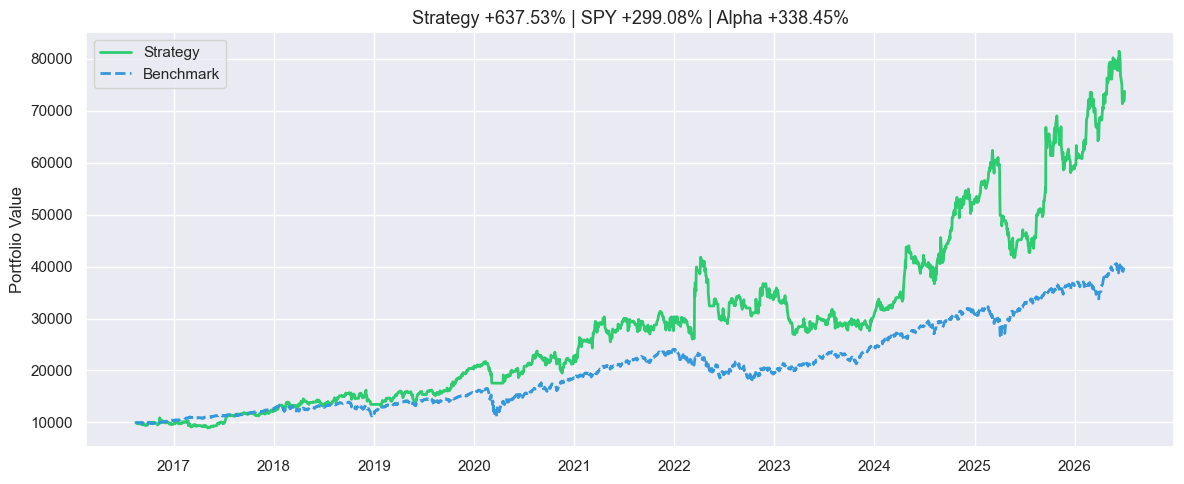

In [14]:
from sklearn import ensemble
rf_classifier = ensemble.RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        min_samples_split=10,
        max_features='sqrt',
        max_depth=10
    )
engine, benchmark_prices = run_with_model(input_model=rf_classifier, features_dict=features)
plot_results(engine, benchmark_prices)

Fetching historical data for companies: ['NVDA', 'MSFT', 'AAPL', 'AMZN', 'GOOGL', 'META', 'CRM', 'ADBE', 'UNH', 'LLY', 'JNJ', 'PFE', 'ABBV', 'MRK', 'JPM', 'BAC', 'GS', 'BRK-B', 'V', 'MA', 'XOM', 'CVX', 'COP', 'WMT', 'COST', 'PG', 'KO', 'CAT', 'RTX', 'GLD', 'TLT', 'SPY']...


[*********************100%***********************]  32 of 32 completed


Download Complete.

Portfolio Simulation Results
  Train window : 2006-07-03 to 2016-07-01
  Test window  : 2016-07-05 to 2026-07-02
  Strategy Return   : +386.08%
  Benchmark (SPY) : +299.08%
  Alpha             : +87.00%
  Win Rate          : 57.45%
  Total Trades      : 322

Trade Log:
     type ticker       price       date     return
      BUY    CRM   77.577866 2016-08-15        NaN
     SELL    CRM   76.496582 2016-08-24  -1.393804
      BUY   ABBV   43.465321 2016-08-24        NaN
     SELL   ABBV   42.837334 2016-09-02  -1.444800
      BUY    CRM   73.822815 2016-09-02        NaN
     SELL    CRM   72.564590 2016-09-14  -1.704384
      BUY    RTX   51.111984 2016-09-14        NaN
     SELL    RTX   51.564495 2016-09-23   0.885332
      BUY    CRM   69.192924 2016-09-23        NaN
     SELL    CRM   71.394829 2016-10-04   3.182268
      BUY   ABBV   42.089077 2016-10-04        NaN
     SELL   ABBV   41.229813 2016-10-13  -2.041538
      BUY    WMT   19.291098 2016-10-13        

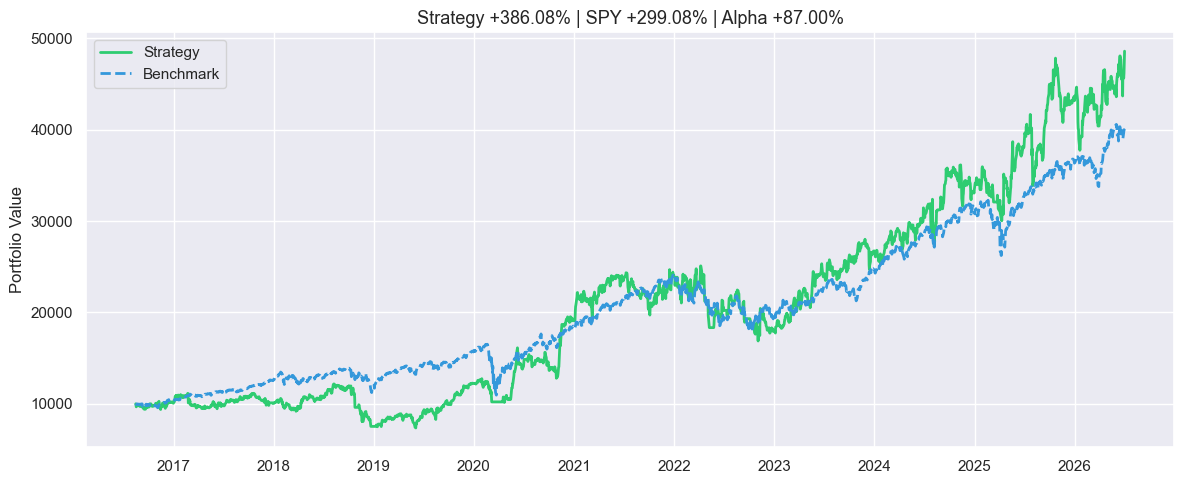

In [4]:
from xgboost import XGBClassifier
xgb_model = XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.05)

engine, benchmark_prices = run_with_model(input_model=xgb_model, features_dict=features)
plot_results(engine, benchmark_prices)

Fetching historical data for companies: ['NVDA', 'MSFT', 'AAPL', 'AMZN', 'GOOGL', 'META', 'CRM', 'ADBE', 'UNH', 'LLY', 'JNJ', 'PFE', 'ABBV', 'MRK', 'JPM', 'BAC', 'GS', 'BRK-B', 'V', 'MA', 'XOM', 'CVX', 'COP', 'WMT', 'COST', 'PG', 'KO', 'CAT', 'RTX', 'GLD', 'TLT', 'SPY']...


[*********************100%***********************]  32 of 32 completed


Download Complete.

Portfolio Simulation Results
  Train window : 2006-07-03 to 2016-07-01
  Test window  : 2016-07-05 to 2026-07-02
  Strategy Return   : +995.63%
  Benchmark (SPY) : +299.08%
  Alpha             : +696.55%
  Win Rate          : 59.08%
  Total Trades      : 325

Trade Log:
     type ticker      price       date     return
      BUY    CRM  77.577873 2016-08-15        NaN
     SELL    CRM  76.496574 2016-08-24  -1.393824
      BUY   ABBV  43.465324 2016-08-24        NaN
     SELL   ABBV  42.837326 2016-09-02  -1.444826
      BUY    CRM  73.822823 2016-09-02        NaN
     SELL    CRM  72.564590 2016-09-14  -1.704394
      BUY    XOM  55.278862 2016-09-14        NaN
     SELL    XOM  54.527424 2016-09-23  -1.359359
      BUY    CRM  69.192932 2016-09-23        NaN
     SELL    CRM  71.394836 2016-10-04   3.182268
      BUY  BRK-B 143.169998 2016-10-04        NaN
     SELL  BRK-B 143.220001 2016-10-13   0.034926
      BUY    PFE  20.077950 2016-10-13        NaN
     SELL

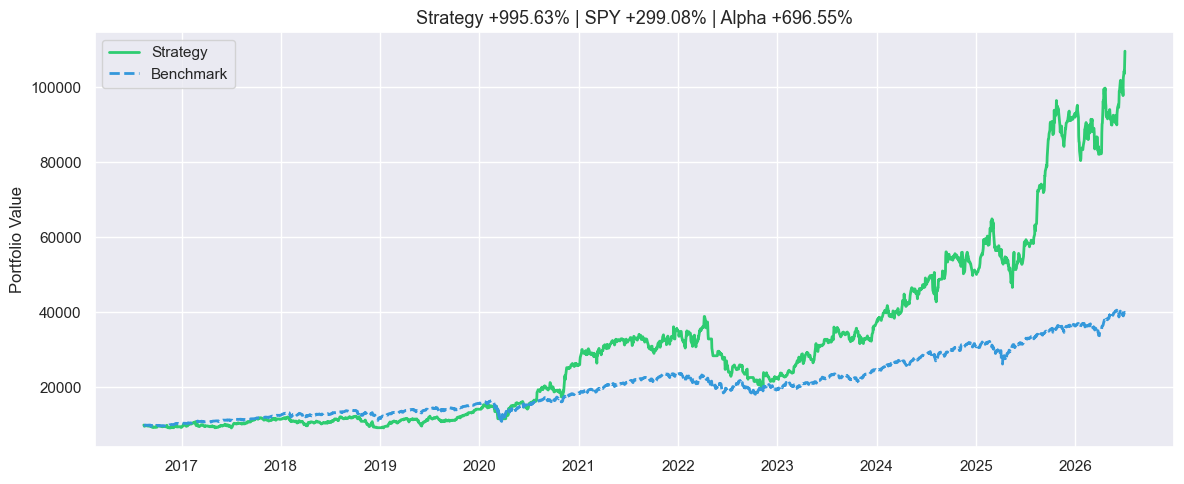

In [5]:
from sklearn.linear_model import LogisticRegression

# There was some noise based on dividing by 0, etc. that we filter out
import warnings
warnings.filterwarnings('ignore')

logreg_model = LogisticRegression(C=0.1)

engine, benchmark_prices = run_with_model(input_model=logreg_model, features_dict=features)
plot_results(engine, benchmark_prices)